# Week 1 Day 6 — Titanic Baseline Project

## What I built:
- Full EDA — 5 visualizations with insights
- Feature engineering — FamilySize, IsAlone, Title, encoded Sex/Embarked
- Trained Logistic Regression and Dummy Classifier
- 5-fold cross validation
- Kaggle submission

## Results:
- Cross-val accuracy : 81.48% ± 1.18%
- Kaggle score       : 0.782
- Dummy baseline     : 61.62%
- Beat baseline by   : 16.6%

## Key findings from EDA:
- Females survived much more than males
- First class survived most
- Children (0-10) had higher survival rate
- Small families survived more than solo or large families
- Mrs title had highest survival rate

## EDA Findings

1. **Gender:** Females survived at much higher rate than males —
   "women and children first" policy.

2. **Class:** First class passengers survived most — better
   access to lifeboats on upper decks.

3. **Age:** Children (0-10) had higher survival rate.
   Most non-survivors were aged 20-35 — largest passenger group.

4. **Family Size:** Small families (2-4) survived more than
   solo travellers or large families (6+).

5. **Title:** Mrs title had highest survival, Mr lowest —
   consistent with gender finding.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

df = pd.read_csv('train.csv')
print(df.shape)
print(df.head())
print(df.isnull().sum())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [2]:
# fill Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# fill Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# drop Cabin — 77% missing, not useful
df = df.drop(columns=['Cabin'])

# verify
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [3]:
# 1. encode Sex — male=0, female=1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# 2. family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 3. is alone
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 4. extract title from name
df['Title'] = df['Name'].apply(lambda name: name.split(',')[1].split('.')[0].strip())
print(df['Title'].value_counts())

# 5. encode Embarked
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print(df[['Sex', 'FamilySize', 'IsAlone', 'Title', 'Embarked']].head())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64
   Sex  FamilySize  IsAlone Title  Embarked
0    0           2        0    Mr         0
1    1           2        0   Mrs         1
2    1           1        1  Miss         0
3    1           2        0   Mrs         0
4    0           1        1    Mr         0


In [4]:
# group rare titles together
def simplify_title(title):
    if title in ['Mr']:
        return 0
    elif title in ['Miss', 'Mlle', 'Ms']:
        return 1
    elif title in ['Mrs', 'Mme']:
        return 2
    elif title in ['Master']:
        return 3
    else:
        return 4  # rare titles — Dr, Rev, Col etc.

df['Title'] = df['Title'].apply(simplify_title)
print(df['Title'].value_counts())

Title
0    517
1    185
2    126
3     40
4     23
Name: count, dtype: int64


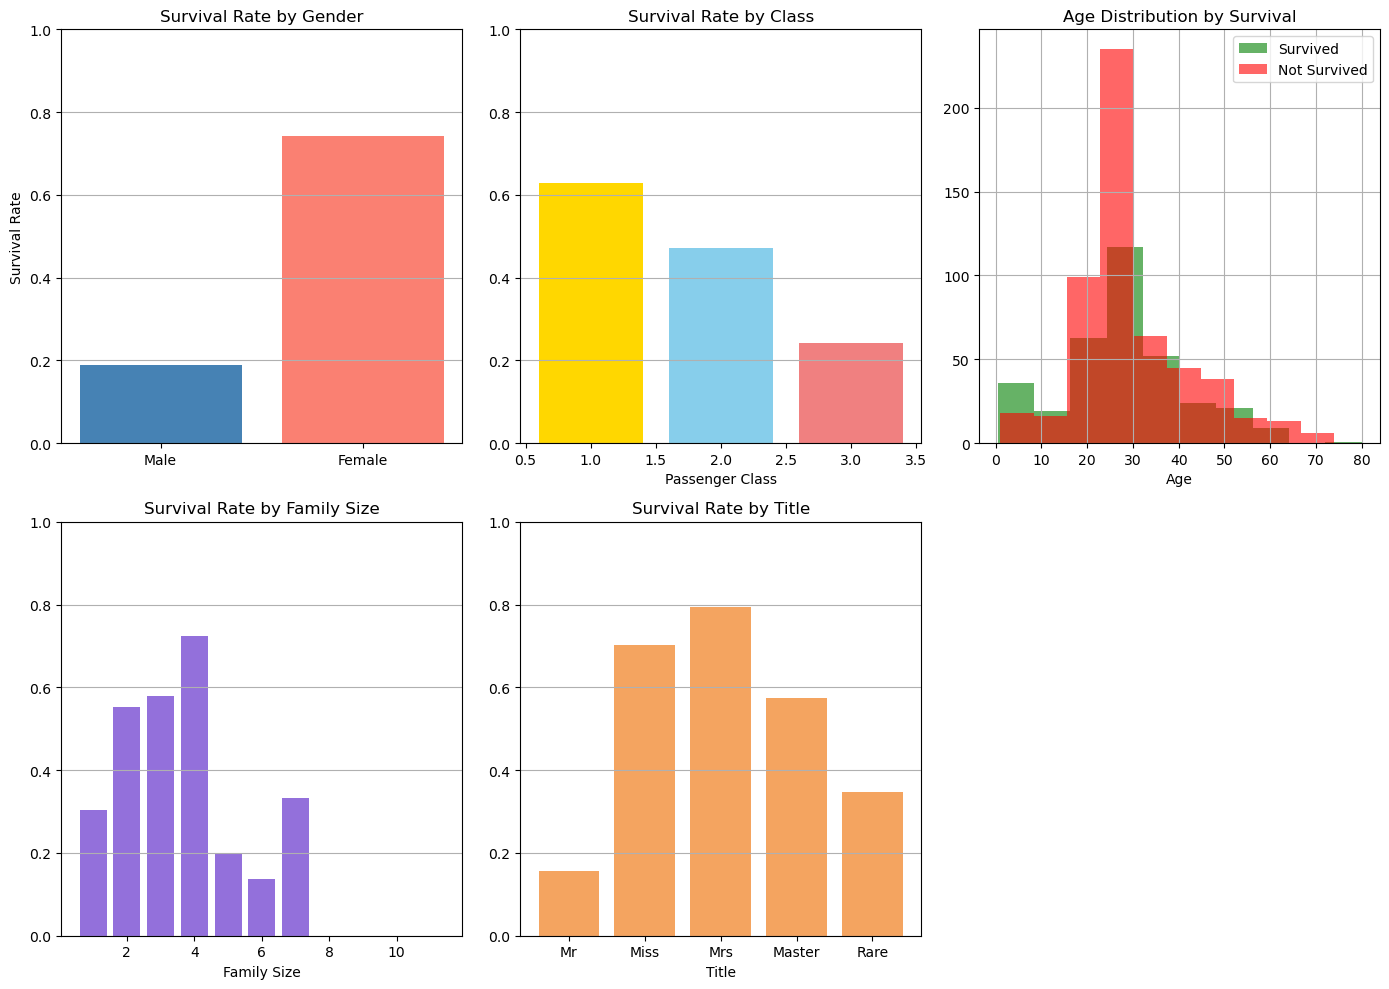

In [5]:
plt.figure(figsize=(14, 10))

# Chart 1 — survival by gender
plt.subplot(2, 3, 1)
survival_gender = df.groupby('Sex')['Survived'].mean()
plt.bar(['Male', 'Female'], survival_gender.values, color=['steelblue', 'salmon'])
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.grid(True, axis='y')

# Chart 2 — survival by class
plt.subplot(2, 3, 2)
survival_class = df.groupby('Pclass')['Survived'].mean()
plt.bar(survival_class.index, survival_class.values, color=['gold', 'skyblue', 'lightcoral'])
plt.title('Survival Rate by Class')
plt.xlabel('Passenger Class')
plt.ylim(0, 1)
plt.grid(True, axis='y')

# Chart 3 — age distribution
plt.subplot(2, 3, 3)
df[df['Survived']==1]['Age'].hist(alpha=0.6, color='green', label='Survived')
df[df['Survived']==0]['Age'].hist(alpha=0.6, color='red', label='Not Survived')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.legend()
plt.grid(True)

# Chart 4 — survival by family size
plt.subplot(2, 3, 4)
survival_family = df.groupby('FamilySize')['Survived'].mean()
plt.bar(survival_family.index, survival_family.values, color='mediumpurple')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylim(0, 1)
plt.grid(True, axis='y')

# Chart 5 — survival by title
plt.subplot(2, 3, 5)
survival_title = df.groupby('Title')['Survived'].mean()
plt.bar(['Mr', 'Miss', 'Mrs', 'Master', 'Rare'],
        survival_title.values, color='sandybrown')
plt.title('Survival Rate by Title')
plt.xlabel('Title')
plt.ylim(0, 1)
plt.grid(True, axis='y')

plt.tight_layout()
plt.savefig('titanic_eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# final features
features = ['Pclass', 'Sex', 'Age', 'Fare', 
            'FamilySize', 'IsAlone', 'Title', 'Embarked']

X = df[features].values
y = df['Survived'].values

# normalize
X_mean = X.mean(axis=0)
X_std  = X.std(axis=0)
X_norm = (X - X_mean) / X_std

# model 1 — logistic regression
lr = LogisticRegression()
lr_scores = cross_val_score(lr, X_norm, y, cv=5, scoring='accuracy')

# model 2 — dummy classifier (baseline)
dummy = DummyClassifier(strategy='most_frequent')
dummy_scores = cross_val_score(dummy, X_norm, y, cv=5, scoring='accuracy')

print("=" * 40)
print("   MODEL COMPARISON")
print("=" * 40)
print(f"  Logistic Regression : {lr_scores.mean():.4f} ± {lr_scores.std():.4f}")
print(f"  Dummy Classifier    : {dummy_scores.mean():.4f} ± {dummy_scores.std():.4f}")
print("=" * 40)

   MODEL COMPARISON
  Logistic Regression : 0.8148 ± 0.0118
  Dummy Classifier    : 0.6162 ± 0.0023


# DummyClassifier = dumbest possible model — sets the minimum bar your real model must beat.


# cross_val_score = tests your model 5 times on different splits — gives reliable accuracy estimate instead of one lucky/unlucky split.

In [7]:
# load test data
test_df = pd.read_csv('test.csv')

# same cleaning as train
test_df['Age']      = test_df['Age'].fillna(test_df['Age'].median())
test_df['Fare']     = test_df['Fare'].fillna(test_df['Fare'].median())
test_df['Embarked'] = test_df['Embarked'].fillna(test_df['Embarked'].mode()[0])

# same feature engineering
test_df['Sex']        = test_df['Sex'].map({'male': 0, 'female': 1})
test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
test_df['IsAlone']    = (test_df['FamilySize'] == 1).astype(int)
test_df['Title']      = test_df['Name'].apply(
                            lambda name: name.split(',')[1]
                                             .split('.')[0].strip())
test_df['Title']      = test_df['Title'].apply(simplify_title)
test_df['Embarked']   = test_df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# prepare features
X_test      = test_df[features].values
X_test_norm = (X_test - X_mean) / X_std

# train on full train data and predict
lr.fit(X_norm, y)
predictions = lr.predict(X_test_norm)

# create submission file
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived':    predictions
})
submission.to_csv('submission.csv', index=False)
print("Submission saved!")
print(submission.head(10))

Submission saved!
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0
